In [5]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import random

In [6]:
# -----------------------------
# 1) Config 
# -----------------------------
CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_2/training_index.csv")
IMG_DIR = Path("../images/corrected_2")
IMG_INDEX_COL = "run_id"  

COL_D = "Dind"
COL_SIGMA = "sigma_eff"

IMG_EXT = ".png"   # image extension
IMG_PREFIX = "mz_binary_"   # image name pattern: mz_binary_<idx>.png

BATCH_SIZE = 10
LR = 5e-5
EPOCHS = 100
VAL_RATIO = 0.1
RANDOM_SEED = 000    #42
MODEL_TYPE = "physics_normal"   # Options: "resnet", "physics", "normal", "physics_normal" 
TRAIN_SURROGATE = True   # whether to train surrogate model or load pre-trained weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [17]:
##def compute_image_observables(img_batch):
##    """
##    Compute physics-informed morphological observables
##    for continuous mz images.
##
##    Parameters
##    ----------
##    img_batch : torch.Tensor
##        Shape [B, 3, H, W], values in [0,1]
##        (Only channel 0 is used)
##
##    Returns
##    -------
##    Phi : torch.Tensor
##        Shape [B, 3], containing:
##        [total_variation, dominant_k, short_range_corr]
##    """
##
##    # -------------------------------------------------
##    # Use only mz channel and shift to [-1, 1]
##    # -------------------------------------------------
##    x = img_batch[:, 0:1, :, :]          # [B,1,H,W]
##    x = 2.0 * x - 1.0                    # [0,1] -> [-1,1]
##
##    B, _, H, W = x.shape
##
##    # =================================================
##    # 1) TOTAL VARIATION (DW density proxy)
##    # =================================================
##    dx = x[..., 1:] - x[..., :-1]
##    dy = x[..., 1:, :] - x[..., :-1, :]
##
##    tv = torch.sqrt(dx**2 + 1e-8).mean(dim=[1,2,3]) + \
##         torch.sqrt(dy**2 + 1e-8).mean(dim=[1,2,3])
##
##    # Normalize by image size (resolution-invariant)
##    tv = tv / (H + W)          # [B]
##
##    # =================================================
##    # 2) DOMINANT WAVEVECTOR (FFT, DC REMOVED)
##    # =================================================
##    x0 = x.squeeze(1)
##    x0 = x0 - x0.mean(dim=[1,2], keepdim=True)   # remove DC
##
##    F = torch.fft.fft2(x0)
##    Fmag = torch.abs(F)
##    Fmag = torch.fft.fftshift(Fmag, dim=[1,2])
##
##    yy, xx = torch.meshgrid(
##        torch.linspace(-1, 1, H, device=x.device),
##        torch.linspace(-1, 1, W, device=x.device),
##        indexing="ij"
##    )
##
##    k = torch.sqrt(xx**2 + yy**2)                 # normalized |k|
##    k = k.unsqueeze(0).expand(B, -1, -1)
##
##    dominant_k = (k * Fmag).sum(dim=[1,2]) / (Fmag.sum(dim=[1,2]) + 1e-8)
##
##    # =================================================
##    # 3) SHORT-RANGE CORRELATION (nearest-neighbor)
##    # =================================================
##    corr_x = (x[..., :-1] * x[..., 1:]).mean(dim=[1,2,3])
##    corr_y = (x[..., :-1, :] * x[..., 1:, :]).mean(dim=[1,2,3])
##
##    corr = 0.5 * (corr_x + corr_y)
##
##    # Normalize correlation to [-1,1]
##    corr = torch.clamp(corr, -1.0, 1.0)
##
##    # =================================================
##    # Stack features
##    # =================================================
##    Phi = torch.stack([tv, dominant_k, corr], dim=1)   # [B,3]
##
##    return Phi
##
def compute_image_observables(img_batch):
    """
    Compute physics-informed morphological observables
    for continuous mz images.

    Parameters
    ----------
    img_batch : torch.Tensor
        Shape [B, 3, H, W], values in [0,1]
        (Only channel 0 is used)

    Returns
    -------
    Phi : torch.Tensor
        Shape [B, 3], containing:
        [dw_density, dominant_k, short_range_corr]
    """

    # -------------------------------------------------
    # Use only mz channel and shift to [-1, 1]
    # -------------------------------------------------
    x = img_batch[:, 0:1, :, :]          # [B,1,H,W]
    x = 2.0 * x - 1.0                    # [0,1] -> [-1,1]

    B, _, H, W = x.shape
    eps = 1e-8

    # =================================================
    # 1) DOMAIN WALL DENSITY (TV-based, well scaled)
    # =================================================
    dx = x[..., 1:] - x[..., :-1]
    dy = x[..., 1:, :] - x[..., :-1, :]
    
    dw_density = (
        torch.sqrt(dx**2 + eps).mean(dim=[1,2,3]) +
        torch.sqrt(dy**2 + eps).mean(dim=[1,2,3])
    )
    
    # Optional: scale to O(1)
    dw_density = dw_density * 0.5


    # =================================================
    # 2) DOMINANT WAVEVECTOR (FFT, DC removed, log-mag)
    # =================================================
    x0 = x.squeeze(1)
    x0 = x0 - x0.mean(dim=[1,2], keepdim=True)   # remove DC

    F = torch.fft.fft2(x0)
    Fmag = torch.abs(F)
    Fmag = torch.fft.fftshift(Fmag, dim=[1,2])

    # Log-compress magnitude
    Fmag = torch.log1p(Fmag)

    # Explicitly zero the DC bin (safety)
    Fmag[:, H//2, W//2] = 0.0

    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, H, device=x.device),
        torch.linspace(-1, 1, W, device=x.device),
        indexing="ij"
    )

    k = torch.sqrt(xx**2 + yy**2)   # normalized radial |k|
    k = k.unsqueeze(0).expand(B, -1, -1)

    dominant_k = (k * Fmag).sum(dim=[1,2]) / (Fmag.sum(dim=[1,2]) + eps)

    # =================================================
    # 3) SHORT-RANGE CORRELATION (nearest neighbor)
    # =================================================
    corr_x = (x[..., :-1] * x[..., 1:]).mean(dim=[1,2,3])
    corr_y = (x[..., :-1, :] * x[..., 1:, :]).mean(dim=[1,2,3])

    corr = 0.5 * (corr_x + corr_y)

    # =================================================
    # Stack features
    # =================================================
    Phi = torch.stack([dw_density, dominant_k, corr], dim=1)   # [B,3]

    return Phi




In [13]:
class MzDataset(Dataset):
    def __init__(self, csv_path, img_dir, index_col,
                 transform=None,
                 target_mean=None,
                 target_std=None):

        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)

        self.img_dir = Path(img_dir)
        self.transform = transform

        self.records = []

        # Find all available images
        img_files = sorted(self.img_dir.glob(f"{IMG_PREFIX}*{IMG_EXT}"))

        if len(img_files) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

        for img_path in img_files:
            # Extract run_id from filename
            try:
                run_id = int(img_path.stem.replace(IMG_PREFIX, ""))
            except ValueError:
                continue  # skip malformed filenames

            # Only keep images that have a matching CSV entry
            if run_id not in self.df.index:
                continue

            row = self.df.loc[run_id]

            self.records.append({
                "img_path": img_path,
                "D": float(row[COL_D]),
                "sigma": float(row[COL_SIGMA]),
                "run_id": run_id
            })

        if len(self.records) == 0:
            raise RuntimeError("No valid (image, label) pairs found.")

        self.target_mean = target_mean
        self.target_std  = target_std

        print(f"[MzDataset] Loaded {len(self.records)} samples from {img_dir}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        # Load image
        img = Image.open(r["img_path"]).convert("L")
        if self.transform is not None:
            img = self.transform(img)

        # Expand to 3 channels (CNN compatibility)
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        # Targets
        target = np.array([r["D"], r["sigma"]], dtype=np.float32)

        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std

        target = torch.tensor(target, dtype=torch.float32)

        return img, target


In [14]:
# ---------------------------------------------------------
# 1. Define transforms
# ---------------------------------------------------------
class RandomRot90:
    def __call__(self, x):
        k = random.randint(0, 3)
        return TF.rotate(x, k * 90)

train_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    RandomRot90(),
    T.ToTensor(),
])

val_tf = T.Compose([
    T.ToTensor(),
])


# ---------------------------------------------------------
# 2. Base dataset (NO transforms yet)
# ---------------------------------------------------------
base_dataset = MzDataset(
    CSV_PATH,
    IMG_DIR,
    IMG_INDEX_COL,
    transform=None
)


# ---------------------------------------------------------
# 3. Train / Val split
# ---------------------------------------------------------
val_size = int(len(base_dataset) * VAL_RATIO)
train_size = len(base_dataset) - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")


# ---------------------------------------------------------
# 4. Inject transforms (CRITICAL STEP)
# ---------------------------------------------------------
train_targets = np.array(
    [[base_dataset.records[i]["D"], base_dataset.records[i]["sigma"]]
     for i in train_dataset.indices],
    dtype=np.float32
)

t_mean = train_targets.mean(axis=0)
t_std  = train_targets.std(axis=0)
t_std[t_std == 0] = 1.0

train_dataset.dataset.transform = train_tf
train_dataset.dataset.target_mean = t_mean
train_dataset.dataset.target_std  = t_std

val_dataset.dataset.transform = val_tf
val_dataset.dataset.target_mean = t_mean
val_dataset.dataset.target_std  = t_std


# ---------------------------------------------------------
# 5. DataLoaders
# ---------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)


[MzDataset] Loaded 388 samples from ../images/corrected_2
Train size: 350, Val size: 38


In [10]:
# -----------------------------
# 4) CNN model
# -----------------------------
class ResNet18Regressor(nn.Module):
    def __init__(self, pretrained=True, freeze_backbone=True):
        super().__init__()
        # Load weights
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        
        # 1. FREEZE BACKBONE (Crucial for small datasets)
        if freeze_backbone and pretrained:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # 2. Modify the final layer
        # We add a small hidden layer to help it learn the relationship
        in_features = self.backbone.fc.in_features
        
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),  # Helps prevent overfitting
            nn.Linear(64, 2)  # Output D and sigma
        )

    def forward(self, x):
        return self.backbone(x)
    
class NormalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Helper: Conv -> BatchNorm -> ReLU -> MaxPool
        # Batch Norm is CRITICAL for training from scratch!
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels), 
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        # 5 layers of downsampling: 512 -> 256 -> 128 -> 64 -> 32 -> 16
        self.features = nn.Sequential(
            conv_block(3, 32),    # Output: [32, 256, 256]
            conv_block(32, 64),   # Output: [64, 128, 128]
            conv_block(64, 128),  # Output: [128, 64, 64]
            conv_block(128, 256), # Output: [256, 32, 32]
            conv_block(256, 512), # Output: [512, 16, 16]
        )
        
        # Global Average Pooling: Turns [512, 16, 16] -> [512, 1, 1]
        # This makes the model "Texture Aware" rather than "Pixel Location Aware"
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),  # High dropout to fight overfitting
            nn.Linear(128, 2)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x
    
    
class PhysicsAugmentedResNet(nn.Module):
    def __init__(self, pretrained=True, freeze_backbone=True):
        super().__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        
        if freeze_backbone and pretrained:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # Remove the original FC layer from backbone
        self.n_features = self.backbone.fc.in_features # 512
        self.backbone.fc = nn.Identity() # Pass through
        
        # Physics features: Edge Density + Magnetization = 2 features
        self.n_physics = 2 
        
        # Fusion Layer
        self.fusion_head = nn.Sequential(
            nn.Linear(self.n_features + self.n_physics, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x, phys):
        # 1. Get Image Features [Batch, 512]
        img_feats = self.backbone(x)
        
        # 2. Concatenate with Physics [Batch, 512+2]
        combined = torch.cat((img_feats, phys), dim=1)
        
        # 3. Predict
        out = self.fusion_head(combined)
        return out
    
    
class PhysicsNormalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Helper: Conv -> BatchNorm -> ReLU -> MaxPool
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        # 1. Image Feature Extractor
        self.features = nn.Sequential(
            conv_block(3, 32),    # -> [32, 256, 256]
            conv_block(32, 64),   # -> [64, 128, 128]
            conv_block(64, 128),  # -> [128, 64, 64]
            conv_block(128, 256), # -> [256, 32, 32]
            conv_block(256, 512), # -> [512, 16, 16]
        )
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # 2. Clean classifier: ONLY uses image features
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)  # Predict D and sigma
        )
        
    def forward(self, x):
        # Extract features
        x = self.features(x)
        x = self.global_pool(x)
        
        # Predict D and sigma
        out = self.classifier(x)
        return out
    
class SurrogatePhysics(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 3)   # Predicts the 3 observables
        )

    def forward(self, params):
        return self.net(params)



In [18]:


class SurrogateDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, device):
        """
        base_dataset: MzDataset SIN transforms
        """
        self.device = device

        # -------------------------------------------------
        # Agrupar índices por (D, sigma)
        # -------------------------------------------------
        groups = {}

        for r in base_dataset.records:
            key = (r["D"], r["sigma"])
            groups.setdefault(key, []).append(r["img_path"])

        self.param_keys = list(groups.keys())
        self.groups = groups

    def __len__(self):
        return len(self.param_keys)

    def __getitem__(self, idx):
        D, sigma = self.param_keys[idx]
        img_paths = self.groups[(D, sigma)]

        return {
            "params": torch.tensor([D, sigma], dtype=torch.float32),
            "img_paths": img_paths
        }
        
surr_dataset = SurrogateDataset(
    base_dataset=base_dataset,
    device=device
)



def compute_phi_bar(img_paths, transform, device):
    Phi_list = []

    for p in img_paths:
        img = Image.open(p).convert("L")
        img = transform(img)          # SOLO ToTensor
        img = img.unsqueeze(0).to(device)

        if img.shape[1] == 1:
            img = img.repeat(1, 3, 1, 1)

        Phi = compute_image_observables(img)
        Phi_list.append(Phi.squeeze(0))

    Phi_bar = torch.stack(Phi_list, dim=0).mean(dim=0)
    return Phi_bar


def compute_phi_stats(surr_dataset, transform, device):
    Phi_all = []

    for item in surr_dataset:
        Phi_bar = compute_phi_bar(item["img_paths"], transform, device)
        Phi_all.append(Phi_bar.cpu())

    Phi_all = torch.stack(Phi_all)
    Phi_mean = Phi_all.mean(dim=0)
    Phi_std  = Phi_all.std(dim=0) + 1e-8

    return Phi_mean.to(device), Phi_std.to(device)

from torch.utils.data import random_split

generator = torch.Generator().manual_seed(RANDOM_SEED)

val_size = int(len(surr_dataset) * VAL_RATIO)
train_size = len(surr_dataset) - val_size

train_surr, val_surr = random_split(
    surr_dataset,
    [train_size, val_size],
    generator=generator
)

from torch.utils.data import random_split

generator = torch.Generator().manual_seed(RANDOM_SEED)

val_size = int(len(surr_dataset) * VAL_RATIO)
train_size = len(surr_dataset) - val_size

train_surr, val_surr = random_split(
    surr_dataset,
    [train_size, val_size],
    generator=generator
)




 TRAINING SURROGATE MODEL g(D, sigma) → <Φ>

Phi mean (train): tensor([0.0096, 0.6592, 0.9740], device='cuda:0')
Phi std  (train): tensor([0.0035, 0.0510, 0.0111], device='cuda:0')
Epoch 001/80 | Train: 1.001436 | Val: 0.542507
Epoch 010/80 | Train: 0.639832 | Val: 0.322194
Epoch 020/80 | Train: 0.632382 | Val: 0.329356
Epoch 030/80 | Train: 0.628313 | Val: 0.330690
Epoch 040/80 | Train: 0.625749 | Val: 0.330060
Epoch 050/80 | Train: 0.623413 | Val: 0.329396
Epoch 060/80 | Train: 0.621666 | Val: 0.328762
Epoch 070/80 | Train: 0.619877 | Val: 0.328332
Epoch 080/80 | Train: 0.618261 | Val: 0.327151

Surrogate saved to 'surrogate_2.pt'


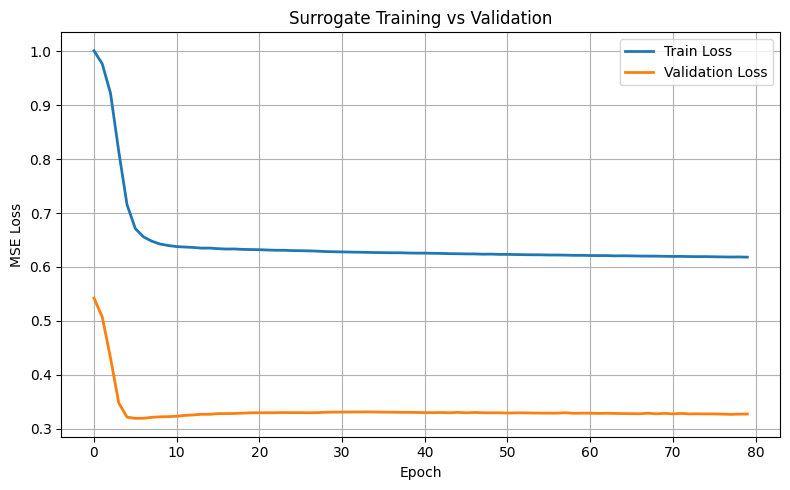

In [9]:
if TRAIN_SURROGATE:

    print("\n==============================")
    print(" TRAINING SURROGATE MODEL g(D, sigma) → <Φ>")
    print("==============================\n")

    surrogate = SurrogatePhysics().to(device)
    optimizer_surr = torch.optim.Adam(surrogate.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    # -------------------------------------------------
    # Compute Φ statistics on TRAIN surrogate set
    # -------------------------------------------------
    Phi_list = []

    with torch.no_grad():
        for item in train_surr:
            img_paths = item["img_paths"]

            imgs = []
            for p in img_paths:
                img = Image.open(p).convert("L")
                img = val_tf(img)          # ONLY ToTensor
                img = img.repeat(3, 1, 1)
                imgs.append(img)

            imgs = torch.stack(imgs).to(device)   # [N,3,H,W]

            Phi = compute_image_observables(imgs) # [N,3]
            Phi_bar = Phi.mean(dim=0)              # [3]

            Phi_list.append(Phi_bar.cpu())

    Phi_all = torch.stack(Phi_list)

    Phi_mean = Phi_all.mean(dim=0)
    Phi_std  = Phi_all.std(dim=0)
    Phi_std[Phi_std == 0] = 1.0

    Phi_mean = Phi_mean.to(device)
    Phi_std  = Phi_std.to(device)

    print("Phi mean (train):", Phi_mean)
    print("Phi std  (train):", Phi_std)

    # -------------------------------------------------
    # Training loop
    # -------------------------------------------------
    epochs = 80
    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):

        # -----------------------------
        # TRAIN
        # -----------------------------
        surrogate.train()
        running_train = 0.0

        for item in train_surr:
            params = item["params"].to(device)
            img_paths = item["img_paths"]

            imgs = []
            for p in img_paths:
                img = Image.open(p).convert("L")
                img = val_tf(img)
                img = img.repeat(3, 1, 1)
                imgs.append(img)

            imgs = torch.stack(imgs).to(device)

            Phi = compute_image_observables(imgs)
            Phi_bar = Phi.mean(dim=0)

            Phi_bar = (Phi_bar - Phi_mean) / Phi_std

            Phi_pred = surrogate(params.unsqueeze(0)).squeeze(0)

            loss = criterion(Phi_pred, Phi_bar)

            optimizer_surr.zero_grad()
            loss.backward()
            optimizer_surr.step()

            running_train += loss.item()

        train_loss = running_train / len(train_surr)
        train_losses.append(train_loss)

        # -----------------------------
        # VALIDATION
        # -----------------------------
        surrogate.eval()
        running_val = 0.0

        with torch.no_grad():
            for item in val_surr:
                params = item["params"].to(device)
                img_paths = item["img_paths"]

                imgs = []
                for p in img_paths:
                    img = Image.open(p).convert("L")
                    img = val_tf(img)
                    img = img.repeat(3, 1, 1)
                    imgs.append(img)

                imgs = torch.stack(imgs).to(device)

                Phi = compute_image_observables(imgs)
                Phi_bar = Phi.mean(dim=0)
                Phi_bar = (Phi_bar - Phi_mean) / Phi_std

                Phi_pred = surrogate(params.unsqueeze(0)).squeeze(0)

                running_val += criterion(Phi_pred, Phi_bar).item()

        val_loss = running_val / len(val_surr)
        val_losses.append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d}/{epochs} | "
                f"Train: {train_loss:.6f} | "
                f"Val: {val_loss:.6f}"
            )

    # -------------------------------------------------
    # Freeze and save
    # -------------------------------------------------
    for p in surrogate.parameters():
        p.requires_grad = False

    surrogate.eval()

    torch.save({
        "state_dict": surrogate.state_dict(),
        "Phi_mean": Phi_mean.detach().cpu(),
        "Phi_std": Phi_std.detach().cpu(),
    }, "surrogate_2.pt")

    print("\nSurrogate saved to 'surrogate_2.pt'")

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss", linewidth=2)
    plt.plot(val_losses, label="Validation Loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Surrogate Training vs Validation")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("surrogate_train_val_curve.png", dpi=300)
    plt.show()


In [19]:
# -----------------------------
# 4) Model Initialization
# -----------------------------

#surrogate = None  # default

if MODEL_TYPE == "resnet":
    model = ResNet18Regressor(
        pretrained=True,
        freeze_backbone=True
    ).to(device)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=1e-3
    )

elif MODEL_TYPE == "normal":
    model = NormalCNN().to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-3
    )

elif MODEL_TYPE == "physics_normal":
    model = PhysicsNormalCNN().to(device)

    # Surrogate MUST exist for this model
    assert os.path.exists("surrogate.pt"), (
        "surrogate.pt not found. Train surrogate before using physics_normal."
    )

    ckpt = torch.load("surrogate.pt", map_location=device)
    surrogate = SurrogatePhysics().to(device)
    surrogate.load_state_dict(ckpt["state_dict"])
    surrogate.eval()

    # Load Phi normalization
    Phi_mean = ckpt["Phi_mean"].to(device)
    Phi_std  = ckpt["Phi_std"].to(device)

    # Freeze surrogate
    for p in surrogate.parameters():
        p.requires_grad = False

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-3
    )

else:
    raise ValueError(f"Unknown MODEL_TYPE: {MODEL_TYPE}")


# -----------------------------
# Loss function
# -----------------------------
criterion = nn.MSELoss()


# -----------------------------
# LR scheduler (monitor TOTAL loss)
# -----------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

best_val_loss = float("inf")
BEST_PATH = "best_regression_model_2.pt"

print(f"Initialized model: {MODEL_TYPE} with LR={LR}")


Initialized model: physics_normal with LR=5e-05


In [20]:
# ============================================================
# 5) Training loop (PINN corrected)
# ============================================================

train_losses = []
val_losses = []
physics_losses = []
lambda_list = []

lambda_data = 1.0

for epoch in range(1, EPOCHS + 1):

    # Physics curriculum
    if MODEL_TYPE == "physics_normal":
        lambda_phys = min(1.0, epoch / 20)
    else:
        lambda_phys = 0.0

    lambda_list.append(lambda_phys)

    # ==========================
    #      TRAIN
    # ==========================
    model.train()
    running_train = 0.0
    running_phys = 0.0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        # Data loss
        loss_data = criterion(outputs, targets)

        if MODEL_TYPE == "physics_normal":
            # True observables (normalized)
            Phi_img = compute_image_observables(imgs)
            Phi_img = (Phi_img - Phi_mean) / Phi_std

            # Surrogate prediction (already normalized)
            Phi_pred = surrogate(outputs)

            loss_phys = F.mse_loss(Phi_pred, Phi_img)
            loss = lambda_data * loss_data + lambda_phys * loss_phys

            running_phys += loss_phys.item() * imgs.size(0)
        else:
            loss = loss_data
            loss_phys = torch.tensor(0.0, device=device)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_train += loss.item() * imgs.size(0)

    epoch_train_loss = running_train / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    epoch_train_phys = running_phys / len(train_loader.dataset)
    physics_losses.append(epoch_train_phys)

    # ==========================
    #      VALIDATION
    # ==========================
    model.eval()
    running_val = 0.0

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            outputs = model(imgs)
            loss_data = criterion(outputs, targets)

            if MODEL_TYPE == "physics_normal":
                Phi_img = compute_image_observables(imgs)
                Phi_img = (Phi_img - Phi_mean) / Phi_std

                Phi_pred = surrogate(outputs)
                loss_phys = F.mse_loss(Phi_pred, Phi_img)

                loss = lambda_data * loss_data + lambda_phys * loss_phys
            else:
                loss = loss_data

            running_val += loss.item() * imgs.size(0)

    epoch_val_loss = running_val / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # ==========================
    #   SCHEDULER & LOG
    # ==========================
    scheduler.step(epoch_val_loss)
    lr_now = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:03d} | "
        f"Train: {epoch_train_loss:.4e} | "
        f"Phys: {epoch_train_phys:.4e} | "
        f"Val: {epoch_val_loss:.4e} | "
        f"λ={lambda_phys:.2f} | "
        f"LR={lr_now:.1e}"
    )

    # Save best model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save({
            "model_state_dict": model.state_dict(),
            "target_mean": t_mean,
            "target_std": t_std,
            "model_type": MODEL_TYPE
        }, BEST_PATH)
        print(" -> Saved new best model.")
        
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.plot(physics_losses, label="Physics Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation vs Physics Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("surrogate_train_val_curve_2.png", dpi=300)
plt.show()


KeyboardInterrupt: 

In [21]:
def get_ground_truth(img_path, csv_path):
    """
    Extracts run_id from filename mz_binary_<run_id>.png
    and looks up D and sigma in CSV.
    """
    filename = Path(img_path).stem  # mz_binary_123
    try:
        run_id = int(filename.split("_")[-1])
    except ValueError:
        raise ValueError(f"Cannot parse run_id from filename: {filename}")

    df = pd.read_csv(csv_path)
    row = df[df[IMG_INDEX_COL] == run_id]

    if row.empty:
        raise KeyError(f"run_id {run_id} not found in CSV")

    return float(row.iloc[0][COL_D]), float(row.iloc[0][COL_SIGMA])

def load_model(path, model_type):
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    if model_type == "resnet":
        model = ResNet18Regressor(pretrained=False).to(device)
    elif model_type == "normal":
        model = NormalCNN().to(device)
    elif model_type == "physics_normal":
        model = PhysicsNormalCNN().to(device)
    else:
        raise ValueError(f"Unsupported model_type: {model_type}")

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    target_mean = checkpoint["target_mean"]
    target_std  = checkpoint["target_std"]

    return model, target_mean, target_std



# Transform for prediction (simple ToTensor, no augmentations)
predict_tf = T.Compose([
    T.ToTensor(),
])



In [22]:
# -----------------------------
# 8) Execution: Predict & Compare
# -----------------------------
# -----------------------------
# Prediction function (cleaned)
# -----------------------------
def predict_image(img_path, model, target_mean, target_std):
    img = Image.open(img_path).convert("L")
    img = predict_tf(img)

    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        out_norm = model(img).cpu().numpy()[0]

    # Unnormalize
    out = out_norm * target_std + target_mean
    return float(out[0]), float(out[1])

model, tm, ts = load_model(BEST_PATH, MODEL_TYPE)

test_img_path = "../images/corrected/mz_binary_4.png"  # example

pred_D, pred_sigma = predict_image(test_img_path, model, tm, ts)
real_D, real_sigma = get_ground_truth(test_img_path, CSV_PATH)

print("-" * 60)
print(f"Model Type: {MODEL_TYPE}")
print(f"Image: {Path(test_img_path).name}")
print("-" * 60)
print(f"{'Parameter':<10} | {'Real':<12} | {'Predicted':<12} | {'Abs Error':<12}")
print("-" * 60)
print(f"{'D':<10} | {real_D:.6f} | {pred_D:.6f} | {abs(pred_D-real_D):.6f}")
print(f"{'Sigma':<10} | {real_sigma:.6f} | {pred_sigma:.6f} | {abs(pred_sigma-real_sigma):.6f}")
print("-" * 60)


------------------------------------------------------------
Model Type: physics_normal
Image: mz_binary_4.png
------------------------------------------------------------
Parameter  | Real         | Predicted    | Abs Error   
------------------------------------------------------------
D          | 0.000184 | 0.000711 | 0.000526
Sigma      | 0.094663 | 0.082799 | 0.011864
------------------------------------------------------------


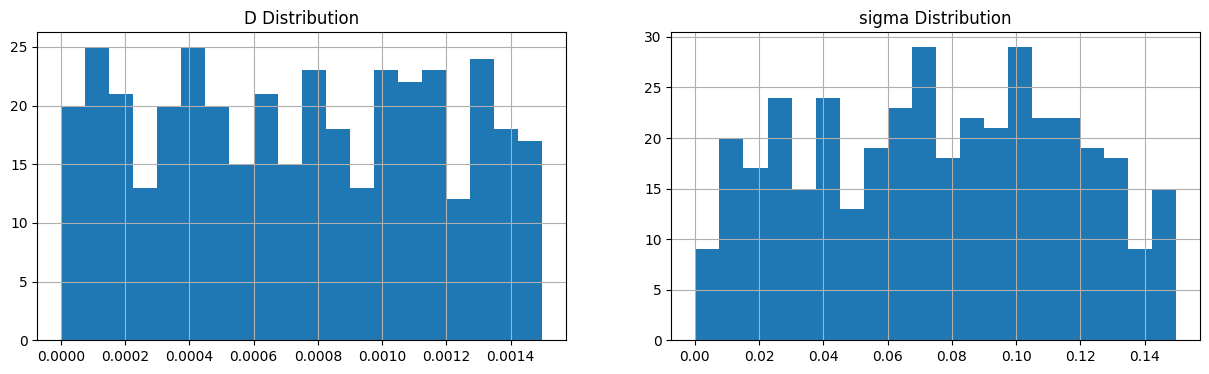

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../mumax_dataset_ku_by_block_disorder_phy_corrected_2/training_index.csv")

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
df["Dind"].hist(bins=20)
plt.title("D Distribution")

plt.subplot(1,2,2)
df["sigma_nominal"].hist(bins=20)
plt.title("sigma Distribution")

plt.show()
